In [29]:
import pandas as pd

In [31]:
mbti = pd.read_csv(r"C:\Users\DELL\Downloads\MBTI 500.csv\MBTI 500.csv")

In [33]:
mbti.shape

(106067, 2)

#### Here the data is unbalanced.

In [38]:
value_cou=mbti.type.value_counts()

<Axes: xlabel='type'>

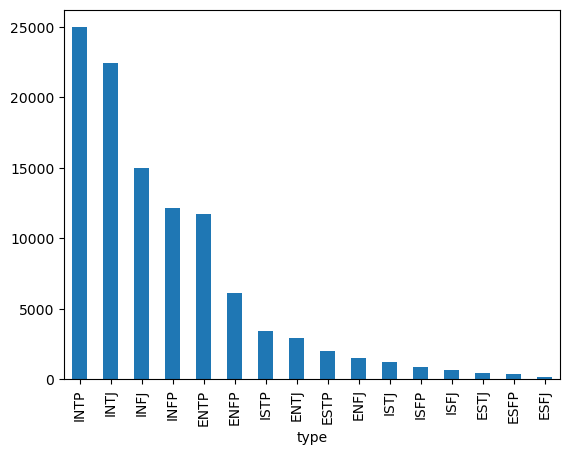

In [40]:
value_cou.plot(kind='bar')

#### I want to make the data balanced, because if it remains this way it will affect the result
#### So I will choose six data types which are "INTP", "INTJ", "INFJ", "INFP", "ENTP", "ENFP"

In [698]:
type_mbti = ["INTP", "INTJ", "INFJ", "INFP", "ENTP", "ENFP"]

In [700]:
df_filter = mbti[mbti.type.isin(type_mbti)]
min_count = df_filter.type.value_counts().min()
df_balanc = df_filter.groupby('type').apply(lambda x: x.sample(min_count,random_state=42)).reset_index(drop=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15856\666485304.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanc = df_filter.groupby('type').apply(lambda x: x.sample(min_count,random_state=42)).reset_index(drop=True)


In [701]:
df_balanc.type.value_counts()

type
ENFP    6167
ENTP    6167
INFJ    6167
INFP    6167
INTJ    6167
INTP    6167
Name: count, dtype: int64

In [702]:
df_balanc.shape

(37002, 2)

<Axes: xlabel='type'>

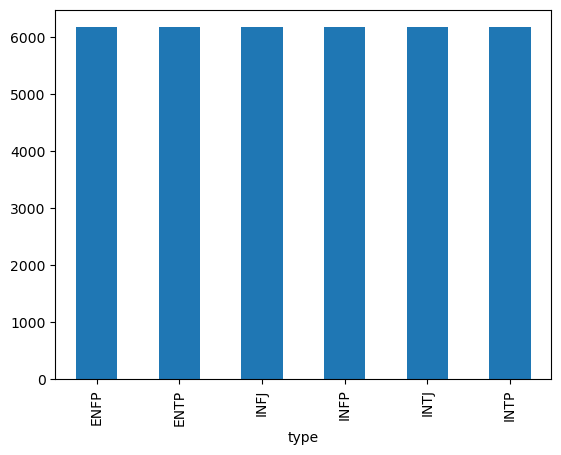

In [706]:
value_cou2=df_balanc.type.value_counts()
value_cou2.plot(kind='bar')

In [708]:
df_balanc.head(2)

,posts,type
0,idea would work figure thing physically expres...,ENFP
1,get field one example obviously advice always ...,ENFP


In [710]:
l1= 'Ah elusive Its question long I remember served bedrock intellectual pursuits Not superficial seeks simple immediate answer kind burrows deep unearthing layers interconnectedness roots concept laid bare Its insatiable curiosity fundamental drive dismantle complexity piece painstaking piece elegant simplicity underlying mechanics revealed This isnt merely academic exercise way lens entire world viewed Consider moment concept progress Many might define visible advancements faster technology greater material wealth longer lifespans But stop would skim surface accept symptom cause My mind immediately dives deeper What truly constitutes progress Is linear cyclical Does inherently lead greater well-being simply greater complexity And foundational drivers perceived progress Is relentless human desire efficiency inherent push towards innovation something far primal perhaps even rooted biological imperative adapt survive To genuinely understand progress one must trace lineage back philosophical discourse economic shifts sociological developments even evolutionary biology The interplay disparate fields often dismissed separate silos knowledge real insights lie Its identifying common threads recurring patterns fundamental principles govern seemingly unrelated phenomena This analytical drive extends beyond abstract concepts tangible world When confronted problem immediate inclination seek quick fix dissect problems anatomy What constituent parts How interact What external forces shaping current manifestation And importantly root causes addressed would eliminate problem entirely rather merely masking symptoms This meticulous deconstruction often reveals surprising interdependencies exposes assumptions upon closer inspection prove flawed incomplete The joy isnt finding answer constructing intellectual scaffolding supports ensuring robustness resilience future scrutiny Its demanding process constant excavation It requires patience willingness challenge ones preconceptions unwavering commitment intellectual honesty There shortcuts true understanding The profound insights rarely reside surface buried deep beneath layers conventional wisdom accepted narratives But us driven relentless pursuit fundamental reward immeasurable Its profound satisfaction truly knowing something grasped essence able articulate intricate workings clarity conviction Its quiet triumph moving beyond mere observation genuine comprehension transforming opaque transparent one time'.lower()
l2 = 'world tapestry woven countless threads truly captivates surface pattern intricate interweaving individual strand collectively form whole life unfolds series events experienced endless invitation disassemble understand happened happened importantly even possible first place isnt choice make simply mind operates inherent gravitational pull towards underlying structure reality quiet moments nature truly reveals simple conversation morph exploration linguistic origins cognitive biases mundane task like fixing leaky faucet becomes deep dive fluid dynamics material science subtle pressures exerted aging infrastructure dont see faucet see marvel human engineering series interconnected systems designed manage fundamental force nature fails question isnt fix fundamental principle design environment allowed failure manifest theres unique kind beauty fundamental truths elegance perfectly balanced equation sublime logic behind complex biological process sheer inventive genius embedded within basic tool beauty often goes unseen content surface level beauty reserved willing peel back layers stare directly intricate machinery existence constant pursuit roots brings profound sense wonder quiet reverence intrinsic order underpins chaos recognition even chaotic phenomena often adhere predictable underlying rules deep diving isnt always easy feel isolating sometimes constantly seek invisible currents others simply navigating visible waves small talk often feels like foreign language collection surface expressions without foundational structure mind craves alternative accept information face value ask persistent neglect intricate dance cause effect feels like betrayal nature would like looking magnificent tree appreciating leaves never considering expansive hidden root system anchors nourishes allows reach skyward satisfaction comes answers answers infinite ever evolving continuous process unveiling quiet satisfaction adding another piece vast intricate puzzle understanding world deepest fundamental core lifelong journey excavation profound endless search ultimate bedrock'
l7 = 'dont walk life straight lines move curves colors rhythms dont always make sense others make perfect sense world live one see one feel one imagine one create driven trends external rewards moves something quieter something internal compass made logic ambition values live chest like soft glowing lights follow lights even lead main path especially theres part feels everything joy music sadness silence tension room word spoken pick carry care maybe thats ive always turned art forms art doesnt argue doesnt demand answers simply allows speak language doesnt bruise express best debate creation drawing writing melody movement pour shapes shadows characters dont exist worlds might process connect breathe conflict hand drains dont mean disagreement mean harsh cutting energy tries win instead understand find shrinking presence dont want fight heard want listened someone cares raised voice louder sometimes people mistake weakness takes strength choose peace world praises fire takes courage walk away noise return rhythm truth ive learned dont explain everyone stay aligned feels right feels real thats north star whether im writing poetry one reads painting scenes understand know creations matter mine honest life doesnt need battle dance canvas poem make someone feel something even moment force quiet magic expression ive done came'
l8 = 'love never interested quick wins theres something hollow chasing things shine moment applause fades shallow conversations temporary rewards prefer depth noise direction speed im impress im build strategy planning understanding landscape reading patterns others overlook anticipating moves happen spend time thinking hesitation discipline every decision make connects something larger dont act todays satisfaction act tomorrows impact independence best thinking work well others dont need crowd validate direction know im going define success alignment purpose many people watching trust judgment ive earned mistakes reflection unshakable commitment learning small talk drains dont mean distant crave conversations mean something want know drives keeps night vision youre working toward surface-level noise ill respectfully step aside dont time spend distractions theres real work done ive always drawn structure chaos fear risk believe calculated risk theres power prepared theres strength intentional goal without plan wish im wish im execute big picture thinking live constantly ask fit whole systems building ripple effects creating dont get lost noise moment im always holding long view keeps focused keeps grounded people sometimes ask im serious truth im passionate care deeply loudly intensity comes vision ego dont need attention need results dont chase approval chase progress world rewards fast loud trendy choose something different depth purpose clarity precision know matters stop wasting energy doesnt'

In [712]:
df_balanc.loc[len(df_balanc)]=[l1,'INTP']
df_balanc.loc[len(df_balanc)]=[l2,'INTP']
df_balanc.loc[len(df_balanc)]=[l7,'INFP']
df_balanc.loc[len(df_balanc)]=[l8,'INTJ']

# Apply TF-IDF

In [715]:
process=df_balanc['posts']

In [717]:
from sklearn.feature_extraction.text import TfidfVectorizer
v_tfidf = TfidfVectorizer()

In [719]:
tf_idf_matrix = v_tfidf.fit_transform(process)

# Apply linear SVC to classification

In [722]:
y = df_balanc['type']

In [724]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
X_train, X_test, y_train, y_test = train_test_split(tf_idf_matrix, y, test_size=0.20, random_state=42)

In [726]:
mod = LinearSVC(C=0.2,dual="auto")
mod.fit(X_train,y_train)

LinearSVC(C=0.2, dual='auto')

In [728]:
mod.score(X_test,y_test)

0.8601729262361524

# test model : Enter a post text or any text of your choice to predict his personality type.

In [731]:
query_tf_idf = v_tfidf.transform(['Ah the elusive why Its a question that has for as long as I can remember served as the bedrock of my intellectual pursuits Not just the superficial why that seeks a simple immediate answer but the kind that burrows deep unearthing layers of interconnectedness until the very roots of a concept are laid bare Its an insatiable curiosity a fundamental drive to dismantle complexity piece by painstaking piece until the elegant simplicity of its underlying mechanics is revealed This isnt merely an academic exercise its a way of being a lens through which the entire world is viewed Consider for a moment the concept of progress Many might define it by visible advancements faster technology greater material wealth longer lifespans But to stop there would be to skim the surface to accept the symptom as the cause My mind immediately dives deeper What truly constitutes progress Is it linear or cyclical Does it inherently lead to greater well-being or simply greater complexity And what are the foundational drivers of this perceived progress Is it the relentless human desire for efficiency the inherent push towards innovation or something far more primal perhaps even rooted in our biological imperative to adapt and survive To genuinely understand progress one must trace its lineage back through philosophical discourse economic shifts sociological developments and even evolutionary biology The interplay of these disparate fields often dismissed as separate silos of knowledge is where the real insights lie Its in identifying the common threads the recurring patterns and the fundamental principles that govern seemingly unrelated phenomena This analytical drive extends beyond abstract concepts to the tangible world When confronted with a problem my immediate inclination is not to seek a quick fix but to dissect the problems anatomy What are its constituent parts How do they interact What are the external forces shaping its current manifestation And most importantly what are the root causes that if addressed would eliminate the problem entirely rather than merely masking its symptoms This meticulous deconstruction often reveals surprising interdependencies and exposes assumptions that upon closer inspection prove to be flawed or incomplete The joy isnt in finding an answer but in constructing the intellectual scaffolding that supports it ensuring its robustness and resilience against future scrutiny Its a demanding process this constant excavation It requires patience a willingness to challenge ones own preconceptions and an unwavering commitment to intellectual honesty There are no shortcuts to true understanding The most profound insights rarely reside on the surface they are buried deep beneath layers of conventional wisdom and accepted narratives But for those of us driven by this relentless pursuit of the fundamental the reward is immeasurable Its the profound satisfaction of truly knowing something of having grasped its essence and of being able to articulate its intricate workings with clarity and conviction Its the quiet triumph of moving beyond mere observation to genuine comprehension of transforming the opaque into the transparent one why at a time'])
predicted=mod.predict(query_tf_idf)
print('\n\n\n',"Personality type is :",predicted[0],'\n \n \n')




 Personality type is : INTP 
 
 



# Model evaluation

In [734]:
y_predict = mod.predict(X_test)

In [736]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_predict)

In [738]:
import numpy as np
labels = np.unique(y_predict)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
df_cm

,ENFP,ENTP,INFJ,INFP,INTJ,INTP
ENFP,1083,28,44,58,30,10
ENTP,18,1073,26,14,39,70
INFJ,38,20,984,62,47,30
INFP,36,19,50,1029,27,34
INTJ,17,20,29,28,1076,67
INTP,8,43,20,29,74,1122


In [740]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [742]:
prec = precision_score(y_test, y_predict,average='macro')   
rec = recall_score(y_test, y_predict,average='macro')       
f1 = f1_score(y_test, y_predict,average='macro')

In [744]:
prec

0.8608648268848175

In [746]:
rec

0.859919236431448

In [748]:
f1

0.8601565857004783